# NB25 — Biais du crowd Winamax vs bonus de score exact MPP

**Objectif.** Le pipeline (`build_exact_score_market` / `exact_score_bonus`) suppose
aujourd'hui que le **crowd Winamax conditionnel** (normalisé par outcome) approxime le
**crowd conditionnel MPP** `cc` qui pilote le barème du bonus de score exact :

| `cc` | bonus |
|---|---|
| > 30 % | 20 |
| 20–30 % | 30 |
| 5–20 % | 50 |
| 0,5–5 % | 70 |
| ≤ 0,5 % | 100 |

On ne connaît pas `cc` MPP, mais pour les **matchs passés** on a relevé la **catégorie
de bonus réelle** (colonne `pts` de `data/exact_scores.csv`) — soit l'intervalle de `cc`.

Ce notebook (1) **quantifie le biais** du barème identité actuel, puis (2) **teste une
simple température** `cc_mpp ∝ cc_wmx^γ` (renormalisée par outcome).

> ⚠️ **Biais de sélection des labels** : MPP n'affiche le bonus que pour le score *courant
> ou final*. Les scores labellisés sont donc surtout des scores *réalisés* (plausibles, `cc`
> élevé) ; la queue rare (bonus 100) est sous-échantillonnée. CV par **match** (jamais par
> score) pour éviter les fuites.

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if 'google.colab' in sys.modules:
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_DIR = Path('/content/drive/MyDrive/Documents/Code/MonPetitPronoStrategy')
    !pip install shin
else:
    PROJECT_DIR = Path.cwd().parent
sys.path.append(str(PROJECT_DIR))
DATA_DIR = PROJECT_DIR / 'data'

from mpp_project.core import (
    build_exact_score_market, calculate_true_outcome_probas_from_odds,
    load_exact_scores_by_match, exact_score_bonus,
)

# Barème : bonus -> intervalle (lo, hi] du crowd conditionnel cc
BAREME = [(0.30, 1.0, 20), (0.20, 0.30, 30), (0.05, 0.20, 50),
          (0.005, 0.05, 70), (0.0, 0.005, 100)]
BONUS_LEVELS = [20, 30, 50, 70, 100]
LVL = {b: i for i, b in enumerate(BONUS_LEVELS)}
def interval_of(b):
    for lo, hi, bb in BAREME:
        if bb == b:
            return lo, hi


## 1. Construction du dataset labellisé

Pour chaque match **passé** (`result` rempli) on construit le marché des scores exacts
(ancré sur le 1N2 du CSV), puis on joint les scores dont le `pts` (bonus réel) est connu.
On mémorise le marché complet par match pour pouvoir renormaliser par outcome (température).

In [2]:
cdm = pd.read_csv(DATA_DIR / 'CDM_2026.csv')
by_match = load_exact_scores_by_match(DATA_DIR / 'exact_scores.csv')
ex = pd.read_csv(DATA_DIR / 'exact_scores.csv')

def is_past(idx):
    return str(cdm.loc[idx, 'result']).strip().lower() not in ('', 'nan', 'none')

records, markets = [], {}   # markets[mid] = (outcomes, cond_crowd) du marché complet
for mid, data in by_match.items():
    idx = mid - 1
    if idx >= len(cdm) or not is_past(idx):
        continue
    odds = cdm.loc[idx, ['cote_1', 'cote_N', 'cote_2']].values.astype(float)
    op = calculate_true_outcome_probas_from_odds(odds)
    mkt = build_exact_score_market(data, outcome_probas=op)
    markets[mid] = (np.asarray(mkt.outcomes), np.asarray(mkt.cond_crowd, float))
    sub = ex[(ex.match_id == mid) & ex.pts.notna()]
    pts_map = {str(s).strip(): int(p) for s, p in zip(sub.score, sub.pts)}
    for k, sc in enumerate(mkt.scores):
        if sc in pts_map:
            b1, b2 = (int(x) for x in sc.split('-'))
            records.append(dict(
                mid=mid, k=k, score=sc, outcome=int(mkt.outcomes[k]),
                cc_wmx=float(mkt.cond_crowd[k]), p_score=float(mkt.p_score[k]),
                tot=b1 + b2, diff=abs(b1 - b2), is00=(b1 == 0 and b2 == 0),
                draw=(b1 == b2), bonus_true=pts_map[sc], bonus_id=int(mkt.bonus[k]),
            ))

df = pd.DataFrame(records)
n_lab_csv = int(ex.pts.notna().sum())
print(f'{len(df)} scores labellisés exploitables '
      f'(sur {n_lab_csv} pts au CSV ; {n_lab_csv - len(df)} sans cote -> exclus du marché)')
print(f'{df.mid.nunique()} matchs couverts : {sorted(df.mid.unique())}')
df.head(10)


41 scores labellisés exploitables (sur 45 pts au CSV ; 4 sans cote -> exclus du marché)
22 matchs couverts : [np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(23), np.int64(24), np.int64(25)]


,mid,k,score,outcome,cc_wmx,p_score,tot,diff,is00,draw,bonus_true,bonus_id
0,3,5,1-1,1,0.666667,0.127557,2,0,False,True,20,20
1,4,20,4-1,0,0.000000,0.012469,5,3,False,False,100,100
2,5,0,0-0,1,0.666667,0.044702,0,0,True,True,50,20
3,5,1,0-1,2,0.065217,0.121604,1,1,False,False,50,50
4,5,8,1-1,1,0.333333,0.050161,2,0,False,True,20,20
5,6,0,0-0,1,0.129032,0.094459,0,0,True,True,70,50
6,6,1,0-1,2,0.100000,0.066930,1,1,False,False,50,50
7,6,2,0-2,2,0.100000,0.026416,2,2,False,False,20,50
8,7,1,0-1,2,0.116279,0.100197,1,1,False,False,50,50
9,8,13,2-0,0,0.200000,0.027617,2,2,False,False,50,50


## 2. Diagnostic du biais (barème identité actuel)

Le barème identité applique `exact_score_bonus(cc_wmx)`. On compare au bonus réel.

In [3]:
df['err_id'] = [LVL[p] - LVL[t] for t, p in zip(df.bonus_true, df.bonus_id)]
# err < 0  => identité prédit un bonus PLUS PETIT que le vrai => cc_wmx trop ÉLEVÉ
#            (Winamax SUR-pondère ce score vs MPP)
acc = (df.bonus_true == df.bonus_id).mean()
w1 = (df.err_id.abs() <= 1).mean()
print('Barème IDENTITÉ (pipeline actuel) :')
print(f'  exact          : {acc:.1%}')
print(f'  à ±1 catégorie : {w1:.1%}')
print(f'  erreur signée moyenne : {df.err_id.mean():+.2f} catégorie '
      f'(quasi nulle => pas de biais GLOBAL)')
print()
cm = (pd.crosstab(df.bonus_true, df.bonus_id)
        .reindex(index=BONUS_LEVELS, columns=BONUS_LEVELS, fill_value=0))
print('Confusion (lignes = vrai bonus, colonnes = bonus identité) :')
print(cm)


Barème IDENTITÉ (pipeline actuel) :
  exact          : 61.0%
  à ±1 catégorie : 82.9%
  erreur signée moyenne : -0.07 catégorie (quasi nulle => pas de biais GLOBAL)

Confusion (lignes = vrai bonus, colonnes = bonus identité) :
bonus_id    20   30   50   70   100
bonus_true                         
20            7    0    2    0    1
30            1    1    2    0    0
50            3    3    8    1    0
70            0    1    1    7    0
100           0    0    0    1    2


In [4]:
# Décomposition de l'erreur signée par FORME de score : c'est là que vit le biais.
def grp(name, mask):
    s = df[mask]
    return dict(groupe=name, n=len(s), err_moy=round(s.err_id.mean(), 2),
                part_sous_estim=round((s.err_id < 0).mean(), 2))
bias = pd.DataFrame([
    grp('global', df.index == df.index),
    grp('score 0-0', df.is00),
    grp('nuls (b1=b2)', df.draw),
    grp('non-nuls', ~df.draw),
])
print('err_moy < 0 => identité SOUS-estime le bonus (Winamax sur-pondère le score vs MPP)')
bias


err_moy < 0 => identité SOUS-estime le bonus (Winamax sur-pondère le score vs MPP)


,groupe,n,err_moy,part_sous_estim
0,global,41,-0.07,0.24
1,score 0-0,8,-1.50,1.00
2,nuls (b1=b2),17,-0.41,0.47
3,non-nuls,24,0.17,0.08


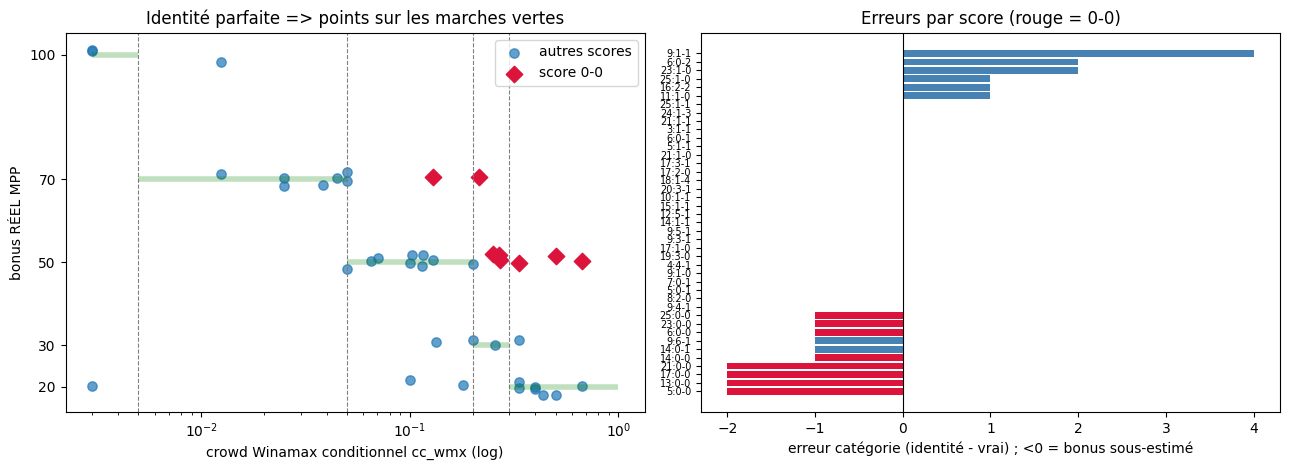

In [5]:
# Visualisation : cc_wmx (log) vs bonus réel, marches du barème en vert.
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

ax = axes[0]
for t in [0.005, 0.05, 0.20, 0.30]:
    ax.axvline(t, color='grey', ls='--', lw=0.8)
for (lo, hi, b) in BAREME:
    ax.hlines(b, max(lo, 3e-3), min(hi, 1.0), color='green', lw=4, alpha=0.25)
jit = (np.random.RandomState(0).rand(len(df)) - 0.5) * 4
m0 = df.is00.values
ax.scatter(np.maximum(df.cc_wmx[~m0], 3e-3), df.bonus_true[~m0] + jit[~m0],
           s=45, alpha=0.7, label='autres scores')
ax.scatter(np.maximum(df.cc_wmx[m0], 3e-3), df.bonus_true[m0] + jit[m0],
           s=70, color='crimson', marker='D', label='score 0-0')
ax.set_xscale('log')
ax.set_xlabel('crowd Winamax conditionnel cc_wmx (log)')
ax.set_ylabel('bonus RÉEL MPP'); ax.set_yticks(BONUS_LEVELS)
ax.set_title('Identité parfaite => points sur les marches vertes')
ax.legend()

ax = axes[1]
order = df.sort_values('err_id')
colors = ['crimson' if x else 'steelblue' for x in order.is00]
ax.barh(range(len(order)), order.err_id, color=colors)
ax.set_yticks(range(len(order)))
ax.set_yticklabels([f'{m}:{s}' for m, s in zip(order.mid, order.score)], fontsize=7)
ax.axvline(0, color='k', lw=0.8)
ax.set_xlabel('erreur catégorie (identité - vrai) ; <0 = bonus sous-estimé')
ax.set_title('Erreurs par score (rouge = 0-0)')
plt.tight_layout(); plt.show()


## 3. Test d'une simple température `cc_mpp ∝ cc_wmx^γ`

Renormalisée **par outcome** (dans chaque match). `γ > 1` concentre la foule, `γ < 1`
l'aplatit. On fitte `γ` par une **loss censurée par intervalle** (le label ne donne que
l'intervalle de `cc`) en **log-espace** : pénalité nulle si le `cc` prédit tombe dans le
bon intervalle, sinon distance log au seuil violé. Robuste à la fonction en escalier.

In [6]:
def cc_temp(gamma, eps=0.0):
    """cc corrigé (température) pour chaque score labellisé. eps = plancher sur cc_wmx."""
    out = np.empty(len(df))
    for r, row in enumerate(df.itertuples()):
        outc, cc = markets[row.mid]
        v = np.maximum(cc, eps)
        mask = outc == row.outcome
        w = v[mask] ** gamma
        w = w / w.sum()
        pos = np.where(np.where(mask)[0] == row.k)[0][0]
        out[r] = w[pos]
    return out

def censored_loss(gamma, eps=0.0):
    cc = np.clip(cc_temp(gamma, eps), 1e-9, 1.0)
    loss = 0.0
    for c, b in zip(cc, df.bonus_true):
        lo, hi = interval_of(b); lc = np.log(c)
        if lo > 0:    loss += max(0.0, np.log(lo) - lc)
        if hi < 1.0:  loss += max(0.0, lc - np.log(hi))
    return loss

def scores(gamma, eps=0.0):
    cc = cc_temp(gamma, eps)
    pred = np.array([exact_score_bonus(c) for c in cc])
    err = np.array([LVL[p] - LVL[t] for t, p in zip(df.bonus_true, pred)])
    return (pred == df.bonus_true.values).mean(), (np.abs(err) <= 1).mean(), pred

grid = np.linspace(0.2, 4.0, 381)
loss_curve = np.array([censored_loss(g) for g in grid])
g_star = grid[loss_curve.argmin()]

acc_id, w1_id, _ = scores(1.0)
acc_g, w1_g, pred_g = scores(g_star)
print(f'gamma* = {g_star:.3f}   (loss {censored_loss(1.0):.2f} -> {loss_curve.min():.2f})')
print(f'  identité (gamma=1) : exact {acc_id:.1%} | ±1cat {w1_id:.1%}')
print(f'  température gamma*  : exact {acc_g:.1%} | ±1cat {w1_g:.1%}')
print()
print('=> Gain quasi nul : le biais n\'est PAS une concentration globale.')


gamma* = 1.000   (loss 28.40 -> 28.40)
  identité (gamma=1) : exact 61.0% | ±1cat 82.9%
  température gamma*  : exact 61.0% | ±1cat 82.9%

=> Gain quasi nul : le biais n'est PAS une concentration globale.


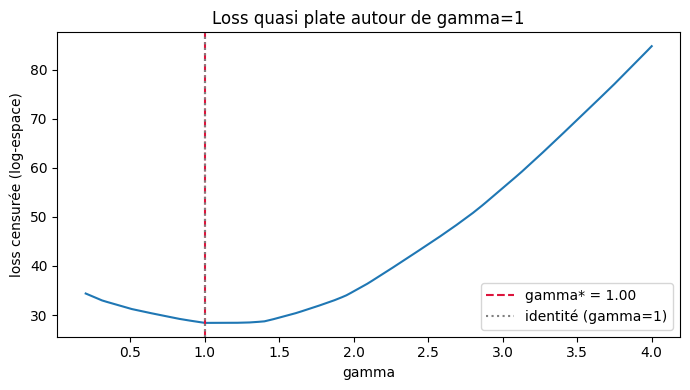

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(grid, loss_curve)
ax.axvline(g_star, color='crimson', ls='--', label=f'gamma* = {g_star:.2f}')
ax.axvline(1.0, color='grey', ls=':', label='identité (gamma=1)')
ax.set_xlabel('gamma'); ax.set_ylabel('loss censurée (log-espace)')
ax.set_title('Loss quasi plate autour de gamma=1'); ax.legend()
plt.tight_layout(); plt.show()


## 4. Ajout du descripteur de forme (indicatrice 0-0)

Le §3 a montré que le biais vit dans la **forme** du score. Modèle enrichi :

$$cc_{mpp}(s) \;\propto\; cc_{wmx}(s)^{\gamma}\;\cdot\;\exp\!\big(\delta\,\mathbb{1}[s=0\text{-}0]\big)$$

renormalisé **par outcome** dans chaque match. `δ < 0` dévalue le 0-0 (sur-pondéré par
Winamax). Fit par la **loss censurée** (§3) + une petite **régularisation L2 vers (γ=1, δ=0)**
— la loss étant nulle sur de larges plateaux (petit échantillon), la régularisation rend la
solution unique et conservatrice. Validation **LOO par match**.

Le terme `total de buts` a aussi été testé : il n'apporte rien à l'exactitude (cf. sortie),
on garde donc le modèle parcimonieux à 2 paramètres.

In [8]:
from scipy.optimize import minimize

# Structure de marché complète (tous les scores) pour renormaliser par outcome.
mk = {}
for mid, data in by_match.items():
    idx = mid - 1
    if idx >= len(cdm) or not is_past(idx):
        continue
    op = calculate_true_outcome_probas_from_odds(
        cdm.loc[idx, ['cote_1', 'cote_N', 'cote_2']].values.astype(float))
    m = build_exact_score_market(data, outcome_probas=op)
    b12 = np.array([[int(x) for x in s.split('-')] for s in m.scores])
    mk[mid] = dict(outc=np.asarray(m.outcomes), cc=np.asarray(m.cond_crowd, float),
                   is00=((b12[:, 0] == 0) & (b12[:, 1] == 0)).astype(float),
                   tot=(b12[:, 0] + b12[:, 1]).astype(float))

LAB = [(int(r.mid), int(r.k), int(r.bonus_true)) for r in df.itertuples()]  # (mid, pos, bonus)
ALLM = set(mk)

def cc_pred(params, model):
    """cc prédit pour chaque label. model in {temp, is00, is00tot}. Garde cc_wmx=0 -> 0."""
    g, out = params[0], []
    for (mid, k, b) in LAB:
        m = mk[mid]; mask = m['outc'] == m['outc'][k]
        cc = m['cc'][mask]
        logw = g * np.log(np.where(cc > 0, cc, 1e-300))
        if model in ('is00', 'is00tot'): logw = logw + params[1] * m['is00'][mask]
        if model == 'is00tot':           logw = logw + params[2] * m['tot'][mask]
        w = np.exp(logw - logw.max())
        w = np.where(cc > 0, w, 0.0); s = w.sum(); w = w / s if s > 0 else w
        pos = np.where(np.where(mask)[0] == k)[0][0]
        out.append((mid, b, w[pos]))
    return out

def loss(params, model, fit_mids, lam=0.05):
    L = 0.0
    for (mid, b, c) in cc_pred(params, model):
        if mid not in fit_mids: continue
        lo, hi = interval_of(b); lc = np.log(max(c, 1e-12))
        if lo > 0:   L += max(0.0, np.log(lo) - lc)
        if hi < 1.0: L += max(0.0, lc - np.log(hi))
    return L + lam * ((params[0] - 1.0) ** 2 + sum(p ** 2 for p in params[1:]))

def fit(model, fit_mids):
    x0 = {'temp': [1.0], 'is00': [1.0, 0.0], 'is00tot': [1.0, 0.0, 0.0]}[model]
    return minimize(loss, x0, args=(model, fit_mids), method='Nelder-Mead',
                    options=dict(xatol=1e-3, fatol=1e-4, maxiter=2000)).x

def acc(params, model, eval_mids):
    ok = n = w1 = 0
    for (mid, b, c) in cc_pred(params, model):
        if mid not in eval_mids: continue
        pr = exact_score_bonus(c); n += 1
        ok += (pr == b); w1 += (abs(LVL[pr] - LVL[b]) <= 1)
    return ok / n, w1 / n


In [9]:
# --- Fit plein échantillon ---
print('=== Fit plein échantillon ===')
res = {}
for model in ['temp', 'is00', 'is00tot']:
    p = fit(model, ALLM); a, w = acc(p, model, ALLM); res[model] = p
    ps = ', '.join(f'{v:+.3f}' for v in p)
    print(f'  {model:8s} params=[{ps}]  exact={a:.1%}  ±1cat={w:.1%}')

# --- LOO par match (modèles temp et is00) ---
print('\n=== LOO par match ===')
labeled = {mid for (mid, _, _) in LAB}
for model in ['temp', 'is00']:
    ok = n = w1 = 0
    for held in labeled:
        p = fit(model, ALLM - {held})
        for (mid, b, c) in cc_pred(p, model):
            if mid != held: continue
            pr = exact_score_bonus(c); n += 1
            ok += (pr == b); w1 += (abs(LVL[pr] - LVL[b]) <= 1)
    print(f'  {model:8s} LOO  exact={ok/n:.1%}  ±1cat={w1/n:.1%}  (n={n})')

g, d = res['is00']
print(f'\nModèle retenu (is00) : γ={g:.3f}, δ={d:.3f}  '
      f'=> poids 0-0 MPP = exp(δ) = {np.exp(d):.0%} de son poids Winamax conditionnel.')


=== Fit plein échantillon ===
  temp     params=[+1.000]  exact=65.9%  ±1cat=82.9%


  is00     params=[+1.033, -1.841]  exact=78.0%  ±1cat=92.7%


  is00tot  params=[+1.137, -2.388, -0.210]  exact=75.6%  ±1cat=95.1%

=== LOO par match ===


  temp     LOO  exact=61.0%  ±1cat=82.9%  (n=41)


  is00     LOO  exact=73.2%  ±1cat=90.2%  (n=41)

Modèle retenu (is00) : γ=1.033, δ=-1.841  => poids 0-0 MPP = exp(δ) = 16% de son poids Winamax conditionnel.


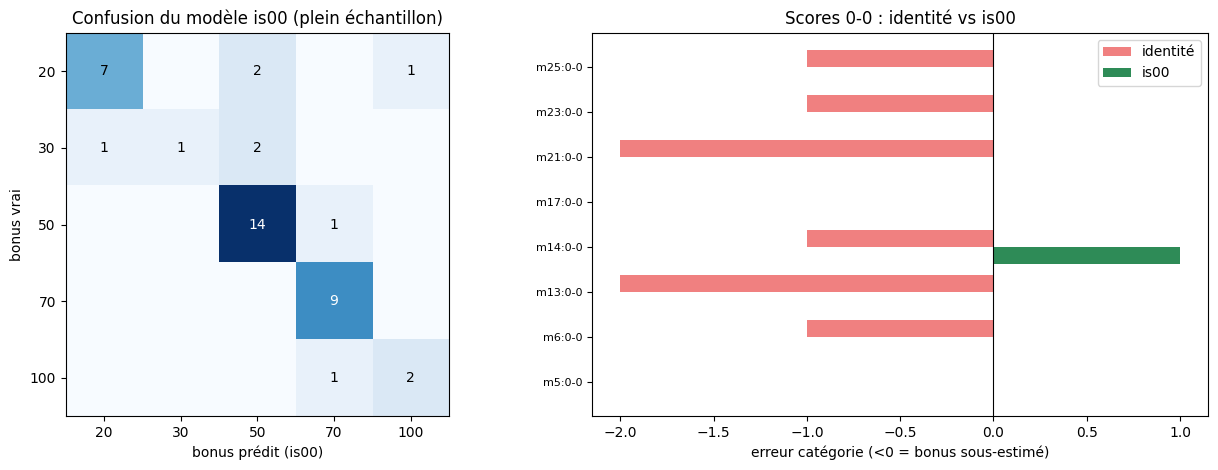

In [10]:
# --- Avant / après : effet sur les scores 0-0 et confusion du modèle is00 ---
g, d = res['is00']
pred_id = {(mid, b): exact_score_bonus(mk[mid]['cc'][k]) for (mid, k, b) in LAB}
pred_s = {(mid, b): exact_score_bonus(c) for (mid, b, c) in cc_pred(res['is00'], 'is00')}

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

# (a) confusion du modèle is00
true = [b for (_, _, b) in LAB]
pis = [pred_s[(mid, b)] for (mid, _, b) in [(m, k, b) for (m, k, b) in LAB]]
cm = pd.crosstab(pd.Series(true, name='vrai'), pd.Series(pis, name='is00')) \
       .reindex(index=BONUS_LEVELS, columns=BONUS_LEVELS, fill_value=0)
ax = axes[0]; im = ax.imshow(cm.values, cmap='Blues')
ax.set_xticks(range(5)); ax.set_xticklabels(BONUS_LEVELS)
ax.set_yticks(range(5)); ax.set_yticklabels(BONUS_LEVELS)
ax.set_xlabel('bonus prédit (is00)'); ax.set_ylabel('bonus vrai')
for i in range(5):
    for j in range(5):
        v = cm.values[i, j]
        if v: ax.text(j, i, v, ha='center', va='center',
                      color='white' if v > cm.values.max()/2 else 'black')
ax.set_title('Confusion du modèle is00 (plein échantillon)')

# (b) erreur catégorie identité vs is00 sur les scores 0-0
is00_lab = [(mid, b) for (mid, k, b) in LAB if mk[mid]['is00'][k] == 1.0]
e_id = [LVL[pred_id[x]] - LVL[x[1]] for x in is00_lab]
e_s = [LVL[pred_s[x]] - LVL[x[1]] for x in is00_lab]
y = np.arange(len(is00_lab)); ax = axes[1]; h = 0.38
ax.barh(y + h/2, e_id, h, label='identité', color='lightcoral')
ax.barh(y - h/2, e_s, h, label='is00', color='seagreen')
ax.axvline(0, color='k', lw=0.8)
ax.set_yticks(y); ax.set_yticklabels([f'm{mid}:0-0' for (mid, _) in is00_lab], fontsize=8)
ax.set_xlabel('erreur catégorie (<0 = bonus sous-estimé)')
ax.set_title('Scores 0-0 : identité vs is00'); ax.legend()
plt.tight_layout(); plt.show()


## Conclusion & prochaines étapes

- **Barème identité** : biais d'échelle global ≈ 0, mais biais **structuré par la forme**
  (les 0-0 sur-pondérés par Winamax vs MPP). La **simple température échoue** (§3).
- **Descripteur de forme `1[0-0]` (§4)** : `cc_mpp ∝ cc_wmx^γ · exp(δ·1[0-0])` fait passer
  l'exactitude de **~61 % → ~73 % en LOO** (±1cat ~82 % → ~90 %). `γ≈1` (Winamax bien
  calibré en échelle), `δ≈−1.8` → le 0-0 MPP ne pèse que ~16 % de son poids Winamax
  conditionnel. Le terme `total de buts` est inutile (modèle parcimonieux à 2 paramètres).

**Productionisation (étape suivante)** : exposer un helper `correct_cond_crowd(cond_crowd,
scores, outcomes, gamma, delta00)` dans `core.py`, l'appeler dans `build_exact_score_market`
AVANT le calcul du bonus (et donc en amont du `cc` consommé par la DP pour Bob/peloton).
Figer `γ`/`δ` en constantes (cf. `CROWD_BETA`), mettre à jour `tests/test_exact_scores`.

**Limites connues** :
- `cc_wmx = 0` (crowd Winamax nul, ex. match 9 `1-1` vrai bonus 20) reste inatteignable :
  un descripteur exogène (popularité de la forme côté MPP, chauvinisme) serait nécessaire.
- Échantillon ~40 labels, biaisé vers les scores réalisés. Recalibrer en cours de tournoi
  quand d'autres `pts` seront relevés.